<a href="https://colab.research.google.com/github/moloruns/Olorunsola_DSPN_S26/blob/master/Exercise7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Exercise 7:  Linear models

This homework assignment is designed to give you practice with linear models and the bias-variance tradeoff.

You will need to download the **unrestricted_trimmed_1_7_2020_10_50_44.csv** file from the *Homework/hcp_data* folder in the class GitHub repository.


This data is a portion of the [Human Connectome Project database](http://www.humanconnectomeproject.org/). It provides measures of cognitive tasks and brain morphology measuresments from 1206 participants. The full description of each variable is provided in the **HCP_S1200_DataDictionary_April_20_2018.csv** file in the *Homework datasets/hcp_data* folder in the class GitHub repository.

---
## 1. Loading the Data (1 point)

Use the `setwd` and `read.csv` functions to load data from the **unrestricted_trimmed_1_7_2020_10_50_44.csv** file.

Using the tidyverse tools, make a new dataframe `d1` that only inclues the subject ID (`Subject`), gender (`Gender`), Flanker Task performance (`Flanker_Unadj`), total white matter volume (`FS_Tot_WM_Vol`), and total grey matter volume (`FS_Total_GM_Vol`) variables and remove all _na_ values.

Use the `head` function to look at the first few rows of each data frame.

In [11]:
# If you are running this on your local computer, wet your workign directory to
# the location of the lexDat data by setting your harddrive. Uncomment this line
# and change the location to where it is on your computer.
#setwd("~/Documents/PittCMU/G3/DSPN/DataSciencePsychNeuro/Homeworks/hcp_data")

# If you are running this on Colab, then use something like this.
# system("gdown --id 1hywRmGdvhbDYTrQRyl1_bLJsq-T3GJq2")

library(tidyverse)
d1 <- read.csv("https://raw.githubusercontent.com/moloruns/Olorunsola_DSPN_S26/refs/heads/master/Exercise%20datasets/hcp_data/unrestricted_trimmed_1_7_2020_10_50_44.csv")
d1 <- d1 |>
  select(Subject, Gender, Flanker_Unadj, FS_Tot_WM_Vol, FS_Total_GM_Vol) |>
  drop_na()
head(d1)

,Subject,Gender,Flanker_Unadj,FS_Tot_WM_Vol,FS_Total_GM_Vol
,<int>,<chr>,<dbl>,<int>,<int>
1,100206,M,130.42,543134,807245
2,100307,F,112.56,407292,664124
3,100408,M,121.18,500417,726206
4,100610,M,126.53,512946,762308
5,101006,F,101.85,429449,579632
6,101107,M,107.04,416995,665024


---
## 2. Initial data visualization (2 point)

Use the `pairs` function to look at all the pairwise scatterplots of the variables in `d1`. Describe which variables seem positively correlated, negatively correlated, or not correlated at all.

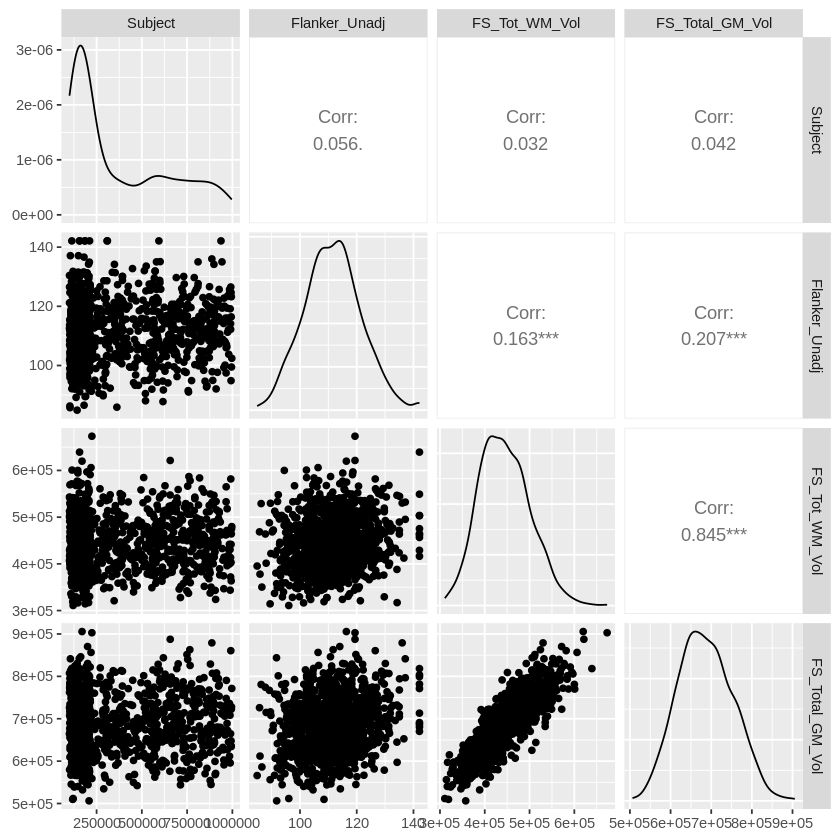

In [18]:
library(GGally)
ggpairs(d1 |> select(-Gender)) # Gender didn't make scatterplots



> Flanker task performance appears to have a weak, positive correlation with total white matter volume and total gray matter volume. Additionally, total gray matter volume seems to have a strong, positive correlation with total white matter volume. Lastly, subject id doesn't appear to be associated with neither flanker task performance, total white matter volume, and total gray matter volume.
>

---
## 3. Linear regression (4 points)

Use the `lm` (linear model) function to determine the association between Flanker Task performance and total grey matter volume from the `d1` data frame.

$$
Y_{flanker} = \beta_0 + \beta_1 X_{GM volume}
$$

Show the results using the `summary` function, and report the mean coefficient values for $beta_0$ \& $\beta_1$ (`coef` function) and their 95\% confidence intervals (`confint` function). Is grey matter volume significantly associated with Flanker Task performance?

---
---

### If you use Generative AI (optional)
If you use code-assisting generative AI (e.g., Copilot, GPT, Claude; more than simple google searching), follow the steps below. If you do not use generative AI, skip this section and go directly to the coding part.

#### Step 1: Write pseudocode

Write pseudocode for `lm` model (or any other variables you have to print) below.

In [ ]:
# Write out your pseudo code here

#### Step 2: Generate code using generative AI
Using your pseudocode, prompt a generative AI to create or fix the R function. Then paste **only the generated function** below.

In [ ]:
# Paste generated function here

#### Step 3: Compare and verify the code

**Question 1.** What is different between your pseudocode and generated code.
(e.g., it handled NAs differently, used a different formula arrangement, etc.)

**Question 2.** What are the input parameters and the output of the function?
(Answer to show you understand what the function takes in and returns. Be concise.)

**Question 3.** Does anything has to be changed? (Yes / No)

> *Write your response here.*

> **Q1.**

> **Q2.**

> **Q3.** Yes / No

If you answers yes to the question 3, revise the code. Don't forget to paste your final version in the code block below.

---
---

In [23]:
flank_wm <- lm(Flanker_Unadj ~ FS_Total_GM_Vol, data = d1)
# summary
summary(flank_wm)
cat("\n")

# coefficients
cat("Mean coefficient value for beta_0:", coef(flank_wm)[0], "\n")
cat("Mean coefficient value for beta_1:", coef(flank_wm)[1], "\n\n")

# confidence interval
confint(flank_wm)



Call:
lm(formula = Flanker_Unadj ~ FS_Total_GM_Vol, data = d1)

Residuals:
     Min       1Q   Median       3Q      Max 
-28.2280  -6.5969  -0.0119   6.5497  31.0108 

Coefficients:
                 Estimate Std. Error t value Pr(>|t|)    
(Intercept)     9.026e+01  3.041e+00  29.677  < 2e-16 ***
FS_Total_GM_Vol 3.110e-05  4.412e-06   7.048 3.18e-12 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 9.864 on 1111 degrees of freedom
Multiple R-squared:  0.0428,	Adjusted R-squared:  0.04194 
F-statistic: 49.68 on 1 and 1111 DF,  p-value: 3.177e-12



Mean coefficient value for beta_0:  
Mean coefficient value for beta_1: 90.25646 



,2.5 %,97.5 %
(Intercept),8.428917e+01,9.622375e+01
FS_Total_GM_Vol,2.244198e-05,3.975733e-05


> Given that the p-value is less than our level of significance (0.05), we have evidence to conclude that total gray matter volume is significantly associated with flanker task performance. This is also supported by the fact that 0 is not included in our confidene interval for the mean coefficient for gray matter volume (must be some sort significant of association as the slope in this linear model is likely not 0).
>

---
## 4. Plotting (2 points)

Use `ggplot` to plot the `FS_Total_GM_Vol` variable (x axis) against the `Flanker_Unadj` variable (y axis), as well as the regression line with confidence intervals on the regrssion line. Qualitatively describe what you see.

`geom_smooth()` using formula = 'y ~ x'


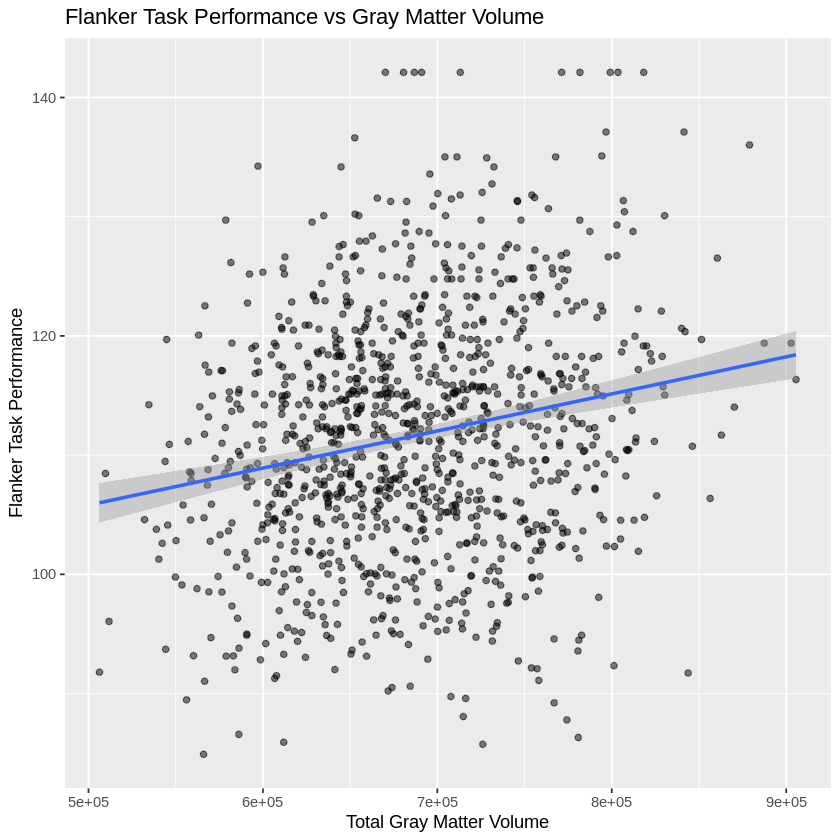

In [27]:
d1 |>
  ggplot(aes(x = FS_Total_GM_Vol, y = Flanker_Unadj)) +
  geom_point(alpha = .5) +
  geom_smooth(method = "lm") +
  labs(y = "Flanker Task Performance",
       x = "Total Gray Matter Volume",
       title = "Flanker Task Performance vs Gray Matter Volume")


> As depicted by the graph, total gray matter volume does appear to be positively associated with flanker task performance. This is supplemented by the (linearly) fitted regression line—its steepness confirms that the estimated association for this model is not 0.
>

---

## 5. Reflection (1 point)

What do you conclude based on the analyses above?

> We reject the notion of there being no association between flanker task performance and total gray matter volume as we have enough evidence to conclude that there is a (statistically) significant relationship between the two variables.
>

**DUE:** 11:59pm EST, Feb 19, 2026

**IMPORTANT** Did you collaborate with anyone on this assignment? If so, list their names here.
> No.